In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,grangercausalitytests
from statsmodels.tsa.stattools import grangercausalitytests


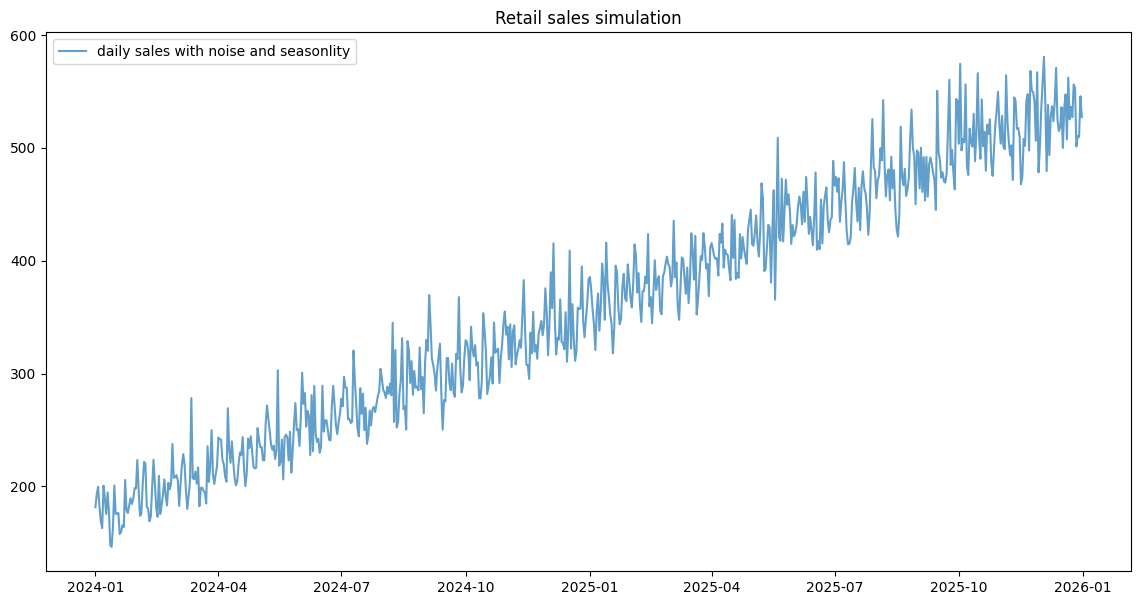

enhanced dataset created
            marketing_spend     profit       sales
2024-01-01        23.936794  19.703331  181.527549
2024-01-02        14.944647  21.780323  193.147462
2024-01-03        13.822836  21.948782  199.639364
2024-01-04        13.823023  18.703631  181.761816
2024-01-05        46.497144  19.590936  169.075225
2024-01-06        28.667062  16.811262  163.047757
2024-01-07        11.310780  19.390952  200.713965
2024-01-08        24.698145  17.415272  189.004352
2024-01-09        19.989603  24.539206  175.450947
2024-01-10         2.159149  20.826607  194.691171


In [45]:

#setup time index
np.random.seed(42)
date_range = pd.date_range(start = '2024-01-01',end = '2025-12-31',freq = 'D')
df = pd.DataFrame(index = date_range)
#get components of the dataset
n = len(df)
time = np.arange(n)

#set tredn
trend = 0.5 *time

#set week seasonlity with sine wave , spikes on weekends
weekly_seasonality = 12*np.sin(2*np.pi*time/7)

#monthly spikes payday spikes
monthly_seasonlaity = 8*np.cos(2*np.pi*time/30.5)

#marketing spend , just random pulses
df['marketing_spend'] = np.random.gamma(shape=2, scale= 10, size = n)
#profit linked with trend
df['profit'] = 20 +(0.15*trend) + np.random.normal(0,3,size = n)

# adding noise , as sales the swing on noise increase
level_dependent_noise = np.random.normal(0,1,size =n)*(1+0.05*trend)
#assemble sales
#marketing impact is delayed by two days
marketing_impact = df['marketing_spend'].shift(2).fillna(df['marketing_spend'].mean())*1.2
df['sales'] = 150+trend+weekly_seasonality+monthly_seasonlaity+marketing_impact+level_dependent_noise


plt.figure(figsize=(14,7))
plt.plot(df.index,df['sales'],label ='daily sales with noise and seasonlity',alpha = 0.7)
plt.title("Retail sales simulation")
plt.legend()
plt.show()
print("enhanced dataset created")
print(df.head(10))

#Frequency check and validation
Purpose: Verify the time series has a proper datetime index with consistentfrequency. This is critical because many time series methods require regular intervals (daily, monthly, etc.) to work correctly.


In [46]:
print("\n Index Check : ")
print(f"index type : {type(df.index)}")
print(f" is datetimeindex : {isinstance(df.index,pd.DatetimeIndex)}") # this code check if index is datetime
# time series analysis requires datetime-aware indes not integer / string

print("\n Frequency Detections : ")
print(f" Frequency : {df.index.inferred_freq}") # the expected value here should be 'D'
# this created daily intervals , if Non it means irregular intervals


print("\n Gap Detection : ") # gap between each observation
date_diffs  = df.index.to_series().diff()
unique_diffs = date_diffs.dropna().unique()
print(f" Unique time differences : {unique_diffs}")
print(f" Number of different invtervals : {len(unique_diffs)}")
# should be 1 , multiple value means irregular spacing

print("\n Missing Dates Checks : ")
expected_range = pd.date_range(start = df.index.min(),end = df.index.max(),freq = "D")
missing_dates = expected_range.difference(df.index )
print(f"Expected number of days : {len(expected_range)}")
print(f" Actual number of days : {len(df)}")
print(f" Missing dates : {len(missing_dates)}")
if len(missing_dates) > 0 :
  print(f" First few missing : {missing_dates[:5].tolist()}")
  # should be 0 as our syenthetic data was created with continous date_range



 Index Check : 
index type : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
 is datetimeindex : True

 Frequency Detections : 
 Frequency : D

 Gap Detection : 
 Unique time differences : <TimedeltaArray>
['1 days']
Length: 1, dtype: timedelta64[ns]
 Number of different invtervals : 1

 Missing Dates Checks : 
Expected number of days : 731
 Actual number of days : 731
 Missing dates : 0


#RESAMPLING DEMONSTRATIONS
transform data to different frequencies (weekly, monthly) this could reveal patterns obscured by daily noise and some models works better with aggregated data (SARIMA on monthly data)

 Original daily records : 731
 weekely records : 105
 Reduction factor : 7.0x

 First 5 weekly averages : 
                 sales     profit  marketing_spend
2024-01-07  184.130448  19.704174        21.857469
2024-01-14  170.787463  22.007787        18.884467
2024-01-21  173.100342  19.455008        14.935087
2024-01-28  183.145268  20.000474        14.974679
2024-02-04  193.637367  21.109435        21.176770

 Monthly resampling (sum for sales, Mean for others )
 Original daily records : 731
 Monthly records : 24
 Reduction factor : 30.5x

 First 5 monthly averages
                  sales     profit  marketing_spend
2024-01-31  5563.700412  20.325487       561.549444
2024-02-29  5699.010408  23.131340       576.100361
2024-03-31  6468.871755  25.030806       587.957736
2024-04-30  6784.994971  27.910139       557.463654
2024-05-31  7460.136077  30.344739       663.197504


/tmp/ipykernel_2856/1625932078.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').agg({


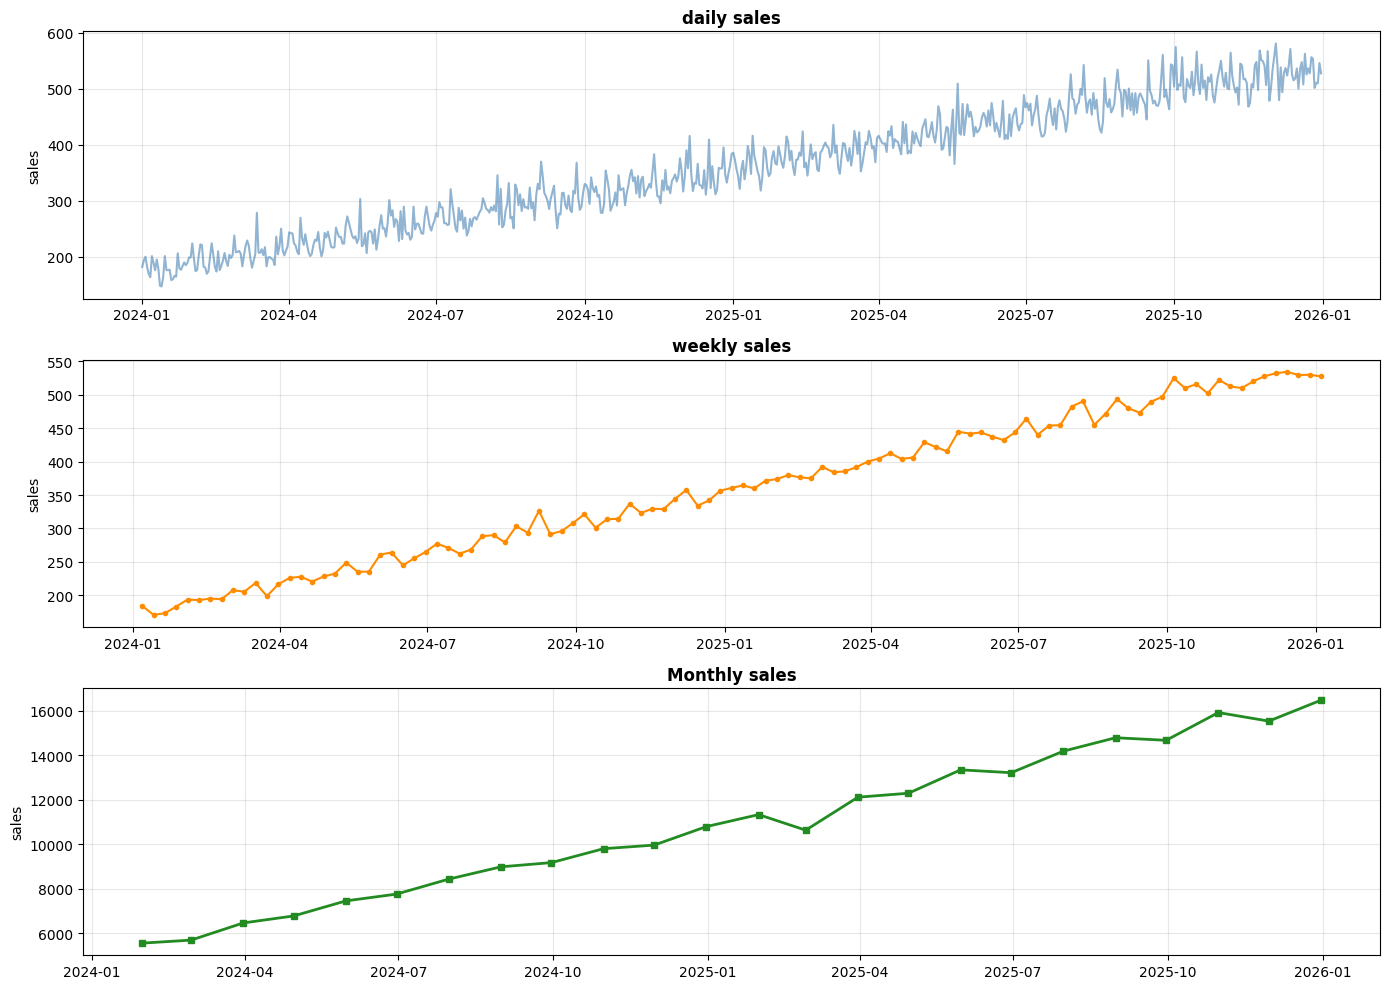

In [61]:
# resampling to weekly aggregations
df_weekly = df[['sales','profit','marketing_spend']].resample("W").mean()
print(f" Original daily records : {len(df)}")
print(f" weekely records : {len(df_weekly)}")
print(f" Reduction factor : {len(df)/len(df_weekly):.1f}x")
print("\n First 5 weekly averages : ")
print(df_weekly.head())

#resampling to monthly aggregation
print("\n Monthly resampling (sum for sales, Mean for others )")
df_monthly = df.resample('M').agg({
    'sales':'sum',
    'profit':'mean',
    'marketing_spend':'sum'
})
print(f" Original daily records : {len(df)}")
print(f" Monthly records : {len(df_monthly)}")
print(f" Reduction factor : {len(df)/len(df_monthly):.1f}x")

print("\n First 5 monthly averages")
print(df_monthly.head()
)

#visualizations
fig,axes = plt.subplots(3,1,figsize = (14,10))

#Daily sales visualiztion
axes[0].plot(df.index,df['sales'],alpha = 0.6, color = 'steelblue')
axes[0].set_title('daily sales',fontsize = 12,fontweight = 'bold')
axes[0].set_ylabel("sales")
axes[0].grid(True, alpha = 0.3)

#weekly visualizations
axes[1].plot(df_weekly.index,df_weekly['sales'],marker='o',markersize=3,color='darkorange',linewidth=1.5)
axes[1].set_title("weekly sales",fontsize=12,fontweight='bold')
axes[1].set_ylabel("sales")
axes[1].grid(True, alpha=0.3)

#Monthly visualizations
axes[2].plot(df_monthly.index,df_monthly['sales'],marker='s',markersize=5,color='forestgreen',linewidth=2)
axes[2].set_title("Monthly sales",fontsize=12,fontweight='bold')
axes[2].set_ylabel("sales")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#TIME SERIES DECOMPOSITION
 Identifying long-term direction (trend)  
 Detecting repeating patterns (seasonality)  
  Assessing model fit quality (residuals should be random noise)

 Trend range : 167.84 to 542.36
 Seasonal range : -13.55 to 13.74
 Residual std dev :18.19
 Mean of residuals : -0.044299


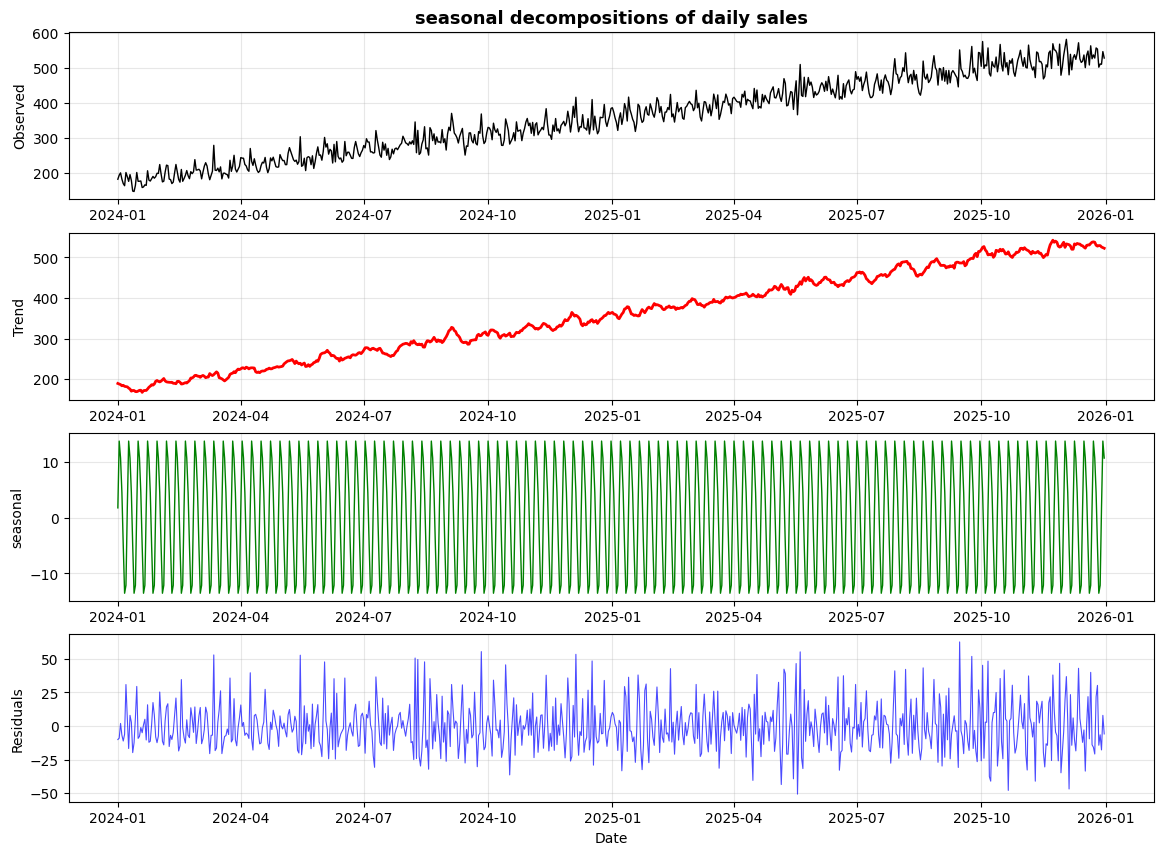

In [70]:
from statsmodels.tsa import seasonal
decomposition = seasonal_decompose(df['sales'], model='additive',period=7,extrapolate_trend='freq')
# extrapolate_trend : to avoid nans at boundaries
trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

print(f" Trend range : {trend_component.min():.2f} to {trend_component.max():.2f}")
print(f" Seasonal range : {seasonal_component.min():.2f} to {seasonal_component.max():.2f}")
print(f" Residual std dev :{residual_component.std():.2f}")
print(f" Mean of residuals : {residual_component.mean():4f}")

#plot decomposotions values
#plot original observed
fig,axes = plt.subplots(4,1,figsize = (14,10))
axes[0].plot(df.index, df['sales'],color='black',linewidth=1)
axes[0].set_ylabel('Observed',fontsize=10)
axes[0].set_title("seasonal decompositions of daily sales",fontsize=13,fontweight="bold")
axes[0].grid(True,alpha=0.3)

#plot trend component
axes[1].plot(df.index,trend_component,color='red',linewidth=2)
axes[1].set_ylabel('Trend',fontsize=10)
axes[1].grid(True,alpha=0.3)

#plot of seasonal
axes[2].plot(df.index,seasonal_component,color='green',linewidth=1)
axes[2].set_ylabel("seasonal",fontsize=10)
axes[2].grid(True,alpha=0.3)

#plot of Residual
axes[3].plot(df.index,residual_component,color='blue',linewidth=0.8,alpha=0.7)
axes[3].set_ylabel("Residuals",fontsize=10)
axes[3].set_xlabel("Date",fontsize=10)
axes[3].grid(True,alpha=0.3)

# AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST
test whether "Sales" dataset is stationary , this important becuase most models require stationary datset which means constant mean and constant variance not trend over time

In [81]:
adf_result = adfuller(df['sales'],autolag="AIC")

#extract results
adf_statistic = adf_result[0]
p_value = adf_result[1]
n_lags = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

#display results
print(f"\nADF Test Statistic : {adf_statistic:.6f}") #More negative = more evidennce not stationary
print(f"P-value : {p_value:.6f}") # if p < 0.05 reject the null "seris is stationary"
print(f"Number of lags used : {n_lags}") #  More lags = test accounts for more autocorrelation structure

print("\nCritical calues :")
for key,value in critical_values.items():
  print(f"{key}:{value:0.4f}") #your statsitic test should be more negative than critical values to say it's stationary data

#interperate results
if p_value < 0.05:
    print(f"✓ P-value ({p_value:.6f}) < 0.05")
    print("  → REJECT null hypothesis")
    print("  → Series IS STATIONARY")
    print("  → Can proceed directly with ARIMA modeling")
else:
    print(f"✗ P-value ({p_value:.6f}) > 0.05")
    print("  → FAIL TO REJECT null hypothesis")
    print("  → Series is NON-STATIONARY")
    print("  → Contains unit root (likely due to trend component)")
    print("  → DIFFERENCING REQUIRED before ARIMA modeling")


# Additional insight: Compare to critical values
print("\nComparison to Critical Values:")
for significance, crit_val in critical_values.items():
    if adf_statistic < crit_val:
        print(f"   ADF ({adf_statistic:.4f}) < {significance} critical value ({crit_val:.4f}) ✓ Stationary at {significance}")
    else:
        print(f"   ADF ({adf_statistic:.4f}) > {significance} critical value ({crit_val:.4f}) ✗ Not stationary at {significance}")


ADF Test Statistic : -0.686932
P-value : 0.850106
Number of lags used : 20

Critical calues :
1%:-3.4396
5%:-2.8656
10%:-2.5689
✗ P-value (0.850106) > 0.05
  → FAIL TO REJECT null hypothesis
  → Series is NON-STATIONARY
  → Contains unit root (likely due to trend component)
  → DIFFERENCING REQUIRED before ARIMA modeling

Comparison to Critical Values:
   ADF (-0.6869) > 1% critical value (-3.4396) ✗ Not stationary at 1%
   ADF (-0.6869) > 5% critical value (-2.8656) ✗ Not stationary at 5%
   ADF (-0.6869) > 10% critical value (-2.5689) ✗ Not stationary at 10%


#turn data to statinoary data
we do this becuase we need to run Granger Test, but if you only fitting data for model you don't need to do this as model will do it automatically

run seasonal difference first if data is stationary you are done , if data is not then run trend which is first time difference


we will use both of them here

 Nan values created 8

 ADF Test on combined diffeerenced Sales : 
   ADF statistics: -9.898424
   Critical value(5%):-2.8657
   ✓ Combined differenced series IS STATIONARY
   → Both trend and seasonality removed


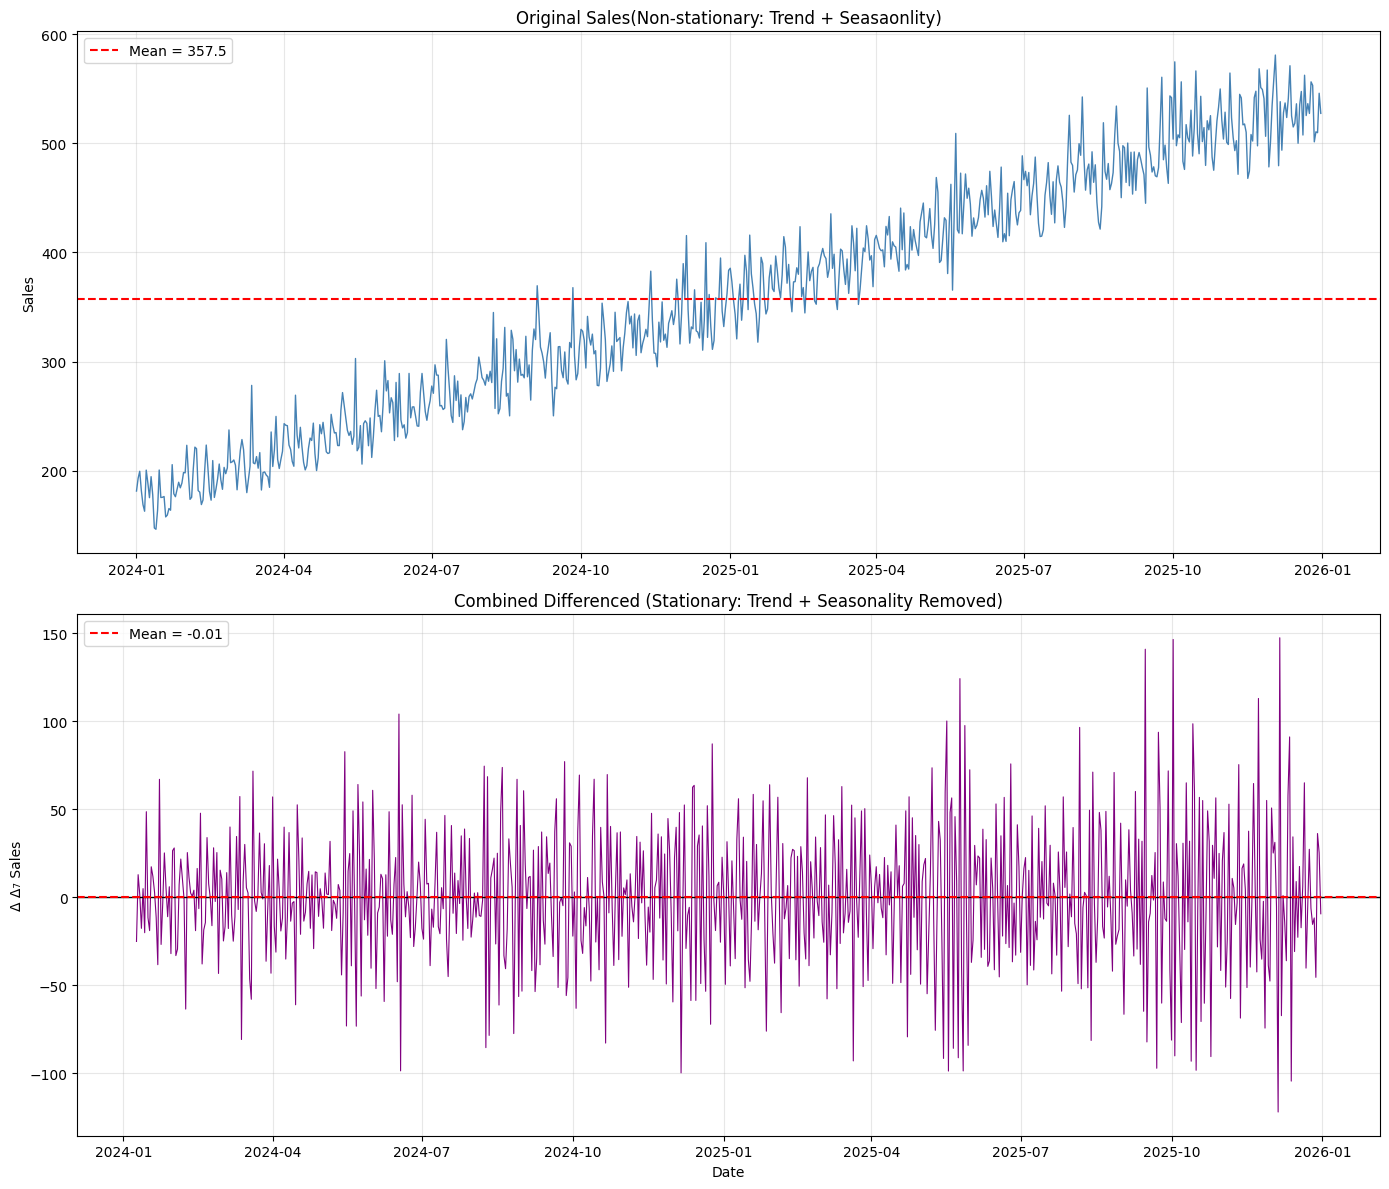

In [104]:
df['sales_diff1_diff7'] = df['sales'].diff(1).diff(7) # applyin trend then seasonal differencing
print(f" Nan values created {df['sales_diff1_diff7'].isna().sum()}")
df_diff_both = df.dropna(subset=['sales_diff1_diff7']).copy()
adf_both = adfuller(df_diff_both['sales_diff1_diff7'].dropna(),autolag ="AIC")
print(f"\n ADF Test on combined diffeerenced Sales : ")
print(f"   ADF statistics: {adf_both[0]:.6f}")
print(f"   Critical value(5%):{adf_both[4]['5%']:.4f}")
if adf_both[1] < 0.05:
  print("   ✓ Combined differenced series IS STATIONARY")
  print("   → Both trend and seasonality removed")
else:
    print("   ✗ Still non-stationary (unexpected)")

#visualization
fig,axes = plt.subplots(2,1,figsize=(14,12))

#original series
axes[0].plot(df.index, df['sales'],color='steelblue',linewidth=1)
axes[0].set_title("Original Sales(Non-stationary: Trend + Seasaonlity)")
axes[0].set_ylabel("Sales")
axes[0].grid(True,alpha=0.3)
axes[0].axhline(y=df['sales'].mean(),color='red',linestyle='--',
                label=f'Mean = {df['sales'].mean():.1f}')
axes[0].legend()



axes[1].plot(df_diff_both.index, df_diff_both['sales_diff1_diff7'],
             color='purple', linewidth=0.8)
axes[1].set_title('Combined Differenced (Stationary: Trend + Seasonality Removed)')
axes[1].set_ylabel('Δ Δ₇ Sales')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=df_diff_both['sales_diff1_diff7'].mean(), color='red', linestyle='--',
                label=f'Mean = {df_diff_both["sales_diff1_diff7"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

#GRANGER CAUSALITY TEST

In [153]:
#Granger causality requires all series to be stationary
# set difference for marketing spend
print("Differencing for markting column")
df['marketing_diff1'] = df['marketing_spend'].diff()
adf_marketing = adfuller(df['marketing_diff1'].dropna(),autolag='AIC')
print(f" ADF p-value(original) : {adfuller(df['marketing_spend'],autolag="AIC")[1]:.6f}")
print(f" ADF p-value(differend): {adf_marketing[1]:.6f}")
if adf_marketing[1]<0.05:
  print(" Marketing spend is stationary after differencing")
else:
  print("  Marketing spend is non-stationary after differencing")
  #actually the original data itself is stationary as it gamma function

#set difference for profit
print("\nDifferencing for markting column")
df['profit_diff1'] = df['profit'].diff()
adf_profit_diff = adfuller(df['profit_diff1'].dropna(),autolag='AIC')
print(f"  ADF p-value (original): {adfuller(df['profit'].dropna(), autolag='AIC')[1]:.6f}")
print(f"  ADF p-value (differenced): {adf_profit_diff[1]:.6f}")
if adf_profit_diff[1] < 0.05:
    print("  Profit is stationary after differencing")
else:
    print("  Profit still non-stationary")

#GRANGER CAUSALITY TESTS
#If p-value < 0.05 → X Granger-causes Y → Include as exogenous
print("\nTEST 1 : Marketing spend is causing Sales")
print("nNull Hypothesis: Marketing spend doesn't help predict sales")
print("Alternative Hypothesis: Marketing spend halp predict sales")
print("Testing lags 1-10 dayes") #actually our data built in 2 days lags
#we expect to reject null hypothesis at lag 2



df_granger = df[['sales_diff1', 'marketing_diff1', 'profit_diff1']].dropna()
print(f"\nDataset for Granger tests: {len(df_granger)} observations")
print("(After removing NaN from differencing)")



try :
  granger_marketing = grangercausalitytests(
      df_granger[['sales_diff1','marketing_diff1']],maxlag=10,verbose=False
  )
  print("\n" + "-" * 70)
  print("Results Summary (F-test p-values):")
  print("-" * 70)
  print(f"{'Lag':<6} {'P-value':<12} {'Conclusion'}")
  print("-" * 70)
  significant_lags=[]
  for lag in range(1,11):
    p_value_f = granger_marketing[lag][0]['ssr_ftest'][1]
    conclusion = "Granger causes" if p_value_f <0.05 else "No Causality"
    print(f"{lag:<6} {p_value_f:<12.6f} {conclusion}")
    if p_value_f <0.05:
      significant_lags.append(lag)

  print("\nINTERPRETATION ")
  if len(significant_lags) > 0:
    print(f"✓ Marketing spend DOES Granger-cause sales at lags: {significant_lags}")
    print(f"   → Past marketing activity helps predict future sales")
    print(f"   → RECOMMENDATION: INCLUDE marketing_spend as EXOGENOUS variable")
    print(f"   → Use lag structure: Consider lags {min(significant_lags)} to {max(significant_lags)}")

    # Expected: Lag 2 should be significant (we built in shift(2))
    if 2 in significant_lags:
      print(f"\n   ⚠ Lag 2 is significant - matches the 2-day delay we built into data!")
  else:
    print("✗ Marketing spend does NOT Granger-cause sales")
    print("   → Past marketing does not help predict sales")
    print("   → RECOMMENDATION: EXCLUDE marketing_spend as exogenous variable")
    print("   → Unexpected! We built in 2-day marketing effect")

except Exception as e:
    print(f"\n⚠ Error in Granger test (Marketing → Sales): {e}")
    print("   Possible issues: Insufficient data, perfect collinearity, or numerical instability")

print("\nImportant Not: ")
print("this code and data should only be granger causes starting from 2 up to 10 and lag at 1 should faile and p > 0.05")
print("data is not perfectly random and most importatn is that we should consider marketing_spend as EXEGENOUS feature\n")


#GRANGER CAUSALITY TESTS
#If p-value < 0.05 → X Granger-causes Y → Include as exogenous
print("\nTEST 2 : Profit is causing Sales")
print("nNull Hypothesis: Marketing spend doesn't help predict sales")
print("Alternative Hypothesis: Marketing spend halp predict sales")
print("Testing lags 1-10 dayes") #actually our data built in 2 days lags
#we expect to reject null hypothesis at lag 2



df_granger = df[['sales_diff1', 'marketing_diff1', 'profit_diff1']].dropna()
print(f"\nDataset for Granger tests: {len(df_granger)} observations")
print("(After removing NaN from differencing)")



try :
  granger_profit = grangercausalitytests(
      df_granger[['sales_diff1','profit_diff1']],maxlag=10,verbose=False
  )
  print("\n" + "-" * 70)
  print("Results Summary (F-test p-values):")
  print("-" * 70)
  print(f"{'Lag':<6} {'P-value':<12} {'Conclusion'}")
  print("-" * 70)
  significant_lags=[]
  for lag in range(1,11):
    p_value_f = granger_profit[lag][0]['ssr_ftest'][1]
    conclusion = "Granger causes" if p_value_f <0.05 else "No Causality"
    print(f"{lag:<6} {p_value_f:<12.6f} {conclusion}")
    if p_value_f <0.05:
      significant_lags.append(lag)

  print("\nINTERPRETATION ")
  if len(significant_lags) > 0:
    print(f"✓ profit spend DOES Granger-cause sales at lags: {significant_lags}")
    print(f"   → Past profit activity helps predict future sales")
    print(f"   → RECOMMENDATION: INCLUDE profit as EXOGENOUS variable")
    print(f"   → Use lag structure: Consider lags {min(significant_lags)} to {max(significant_lags)}")

    # Expected: Lag 2 should be significant (we built in shift(2))
    if 2 in significant_lags:
      print(f"\n   ⚠ Lag 2 is significant - matches the 2-day delay we built into data!")
  else:
    print("✗ profit spend does NOT Granger-cause sales")
    print("   → Past profit does not help predict sales")
    print("   → RECOMMENDATION: EXCLUDE profit as exogenous variable")

except Exception as e:
    print(f"\n⚠ Error in Granger test (Profit → Sales): {e}")
    print("   Possible issues: Insufficient data, perfect collinearity, or numerical instability")



Differencing for markting column
 ADF p-value(original) : 0.000000
 ADF p-value(differend): 0.000000
 Marketing spend is stationary after differencing

Differencing for markting column
  ADF p-value (original): 0.930597
  ADF p-value (differenced): 0.000000
  Profit is stationary after differencing

TEST 1 : Marketing spend is causing Sales
nNull Hypothesis: Marketing spend doesn't help predict sales
Alternative Hypothesis: Marketing spend halp predict sales
Testing lags 1-10 dayes

Dataset for Granger tests: 730 observations
(After removing NaN from differencing)

----------------------------------------------------------------------
Results Summary (F-test p-values):
----------------------------------------------------------------------
Lag    P-value      Conclusion
----------------------------------------------------------------------
1      0.000000     Granger causes
2      0.000000     Granger causes
3      0.000000     Granger causes
4      0.000000     Granger causes
5      0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(



----------------------------------------------------------------------
Results Summary (F-test p-values):
----------------------------------------------------------------------
Lag    P-value      Conclusion
----------------------------------------------------------------------
1      0.871575     No Causality
2      0.896064     No Causality
3      0.946756     No Causality
4      0.978575     No Causality
5      0.416954     No Causality
6      0.600659     No Causality
7      0.694222     No Causality
8      0.297391     No Causality
9      0.116927     No Causality
10     0.120141     No Causality

INTERPRETATION 
✗ profit spend does NOT Granger-cause sales
   → Past profit does not help predict sales
   → RECOMMENDATION: EXCLUDE profit as exogenous variable
   → Unexpected! We built in 2-day marketing effect


#now we will try to find our best model
#first we will try to choose parameter by my self , then we wil use autosairmax


,marketing_spend,profit,sales,sales_diff7,sales_diff1,sales_diff1_diff7,marketing_diff1,profit_diff1
2024-01-01,23.936794,19.703331,181.527549,NaN,NaN,NaN,NaN,NaN
2024-01-02,14.944647,21.780323,193.147462,NaN,11.619914,NaN,-8.992147,2.076992
2024-01-03,13.822836,21.948782,199.639364,NaN,6.491902,NaN,-1.121811,0.168459
2024-01-04,13.823023,18.703631,181.761816,NaN,-17.877548,NaN,0.000187,-3.245152
2024-01-05,46.497144,19.590936,169.075225,NaN,-12.686591,NaN,32.674121,0.887305
